In [1]:
# Import the necessary function from tensorflow.keras.datasets
from tensorflow.keras.datasets import boston_housing

In [2]:
# Load the training and testing data
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Print the shapes of the loaded data to verify
print("Shape of training data (train_data):", train_data.shape)
print("Shape of training targets (train_targets):", train_targets.shape)
print("Shape of testing data (test_data):", test_data.shape)
print("Shape of testing targets (test_targets):", test_targets.shape)

Shape of training data (train_data): (404, 13)
Shape of training targets (train_targets): (404,)
Shape of testing data (test_data): (102, 13)
Shape of testing targets (test_targets): (102,)


In [4]:
# Get the shapes again (optional, but good for clarity in this cell)
train_shape = train_data.shape
test_shape = test_data.shape

# Extract the number of features (attributes) from the shape
# It's the second dimension (index 1)
num_features = train_data.shape[1] # Or test_data.shape[1], should be the same

# Print the answers
print(f"Shape of the training data (train_data): {train_shape}")
print(f"This means there are {train_shape[0]} training samples and {train_shape[1]} features per sample.")

print(f"\nShape of the testing data (test_data): {test_shape}")
print(f"This means there are {test_shape[0]} testing samples and {test_shape[1]} features per sample.")

print(f"\nTotal number of features (attributes): {num_features}")

Shape of the training data (train_data): (404, 13)
This means there are 404 training samples and 13 features per sample.

Shape of the testing data (test_data): (102, 13)
This means there are 102 testing samples and 13 features per sample.

Total number of features (attributes): 13


In [5]:
import numpy as np

# --- Feature Ranges ---
# Combine training and testing features to find the overall range
all_features = np.concatenate((train_data, test_data), axis=0)

# Calculate min and max for each feature column (axis=0)
min_per_feature = np.min(all_features, axis=0)
max_per_feature = np.max(all_features, axis=0)

print("--- Feature Value Ranges (Min/Max) ---")
# Iterate through each feature and print its min/max
for i in range(all_features.shape[1]):
    print(f"Feature {i+1}: Min = {min_per_feature[i]:.2f}, Max = {max_per_feature[i]:.2f}")

# --- Target Ranges ---
# Combine training and testing targets
all_targets = np.concatenate((train_targets, test_targets), axis=0)

# Calculate min and max for the targets
min_target = np.min(all_targets)
max_target = np.max(all_targets)

print("\n--- Target Value Range (Min/Max) ---")
print(f"Target (Price in $1000s): Min = {min_target:.2f}, Max = {max_target:.2f}")

--- Feature Value Ranges (Min/Max) ---
Feature 1: Min = 0.01, Max = 88.98
Feature 2: Min = 0.00, Max = 100.00
Feature 3: Min = 0.46, Max = 27.74
Feature 4: Min = 0.00, Max = 1.00
Feature 5: Min = 0.39, Max = 0.87
Feature 6: Min = 3.56, Max = 8.78
Feature 7: Min = 2.90, Max = 100.00
Feature 8: Min = 1.13, Max = 12.13
Feature 9: Min = 1.00, Max = 24.00
Feature 10: Min = 187.00, Max = 711.00
Feature 11: Min = 12.60, Max = 22.00
Feature 12: Min = 0.32, Max = 396.90
Feature 13: Min = 1.73, Max = 37.97

--- Target Value Range (Min/Max) ---
Target (Price in $1000s): Min = 5.00, Max = 50.00


In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np # Ensure numpy is imported if not already

# 1. Create the scaler instance
scaler = MinMaxScaler()

# 2. Fit the scaler ONLY on the training data
# This learns the min and max values from train_data
scaler.fit(train_data)

# 3. Transform both the training and testing data using the fitted scaler
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

# Verify shapes are unchanged
print("\n--- Shapes after Scaling ---")
print("Shape of scaled_train_data:", scaled_train_data.shape)
print("Shape of scaled_test_data:", scaled_test_data.shape)


--- Shapes after Scaling ---
Shape of scaled_train_data: (404, 13)
Shape of scaled_test_data: (102, 13)


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(input_shape):

  model = keras.Sequential([
      # First hidden layer: 64 neurons, ReLU activation, specify input shape
      layers.Dense(64, activation='relu', input_shape=input_shape),
      # Second hidden layer: 64 neurons, ReLU activation
      layers.Dense(64, activation='relu'),
      # Output layer: 1 neuron (for the single predicted value), no activation (linear)
      layers.Dense(1)
  ])
  return model

In [8]:
# Make sure 'scaled_train_data' is available from task 1d
input_shape_for_model = (scaled_train_data.shape[1],)
model = build_model(input_shape_for_model)

# Compile the model
model.compile(optimizer='adam',           # Adam optimizer
              loss='mse',                # Mean Squared Error loss function
              metrics=['mae'])           # Mean Absolute Error metric to monitor

# Print a confirmation message (optional)
print("Model compiled successfully with:")
print(f" - Optimizer: {model.optimizer.get_config()['name']}") # Get optimizer name
print(f" - Loss function: {model.loss}")
print(f" - Metrics: {model.metrics_names}") # Lists loss and metrics

Model compiled successfully with:
 - Optimizer: adam
 - Loss function: mse
 - Metrics: ['loss', 'compile_metrics']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting model training...
Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 412.2410 - mae: 15.9472 - val_loss: 37.5677 - val_mae: 4.9308
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 64.1868 - mae: 5.8630 - val_loss: 21.0536 - val_mae: 3.6027
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 52.5144 - mae: 5.2384 - val_loss: 22.2815 - val_mae: 3.6296
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29.5235 - mae: 3.8081 - val_loss: 23.2250 - val_mae: 3.5038
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 31.5132 - mae: 4.0351 - val_loss: 24.2456 - val_mae: 3.6491
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.2358 - mae: 3.3318 - val_loss: 23.8226 - val_mae: 3.6512
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 20.2258 - mae: 3.2995 - val_loss: 20.7522 - val_mae: 3.2509
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19.4477 - mae: 3.1503 - val_loss: 20.6839 - val_mae: 3.2699
Epo

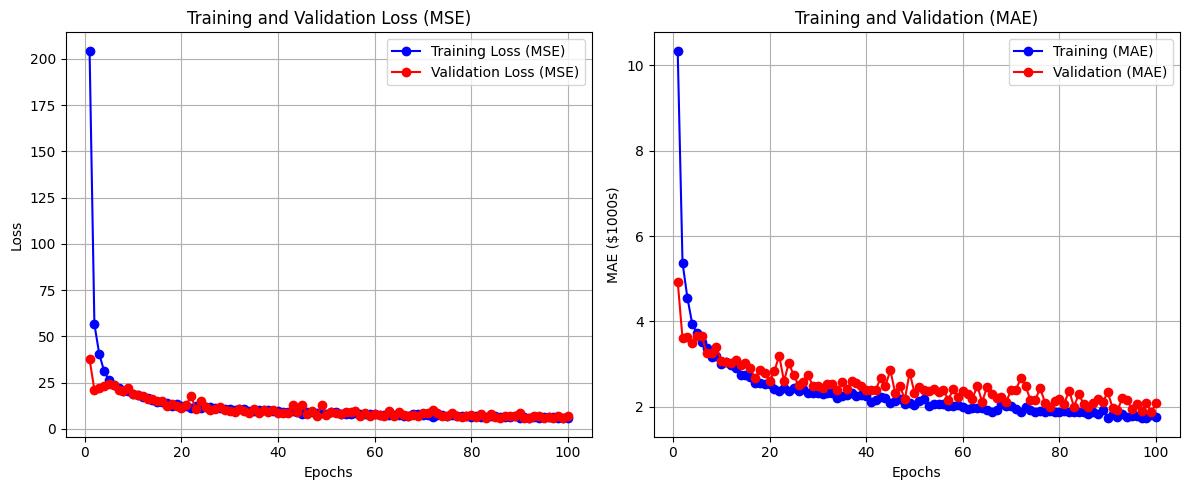

In [9]:
# Task 1g: Train the model and visualize history

import matplotlib.pyplot as plt
import numpy as np

# Define training parameters
epochs = 100
batch_size = 1
validation_split = 0.1

# --- Train the Model ---
print("Starting model training...")
# We use the scaled training data and the original (unscaled) training targets
history = model.fit(scaled_train_data,         # Input features (scaled)
                    train_targets,             # Target values (original scale)
                    epochs=epochs,             # Number of training cycles
                    batch_size=batch_size,     # Number of samples per gradient update
                    validation_split=validation_split, # Fraction of training data for validation
                    verbose=1)                 # Set verbose=1 to see progress per epoch, 0 for silent

print("\nTraining finished.")

# --- Report Final Metrics ---
# Access the history object returned by model.fit()
history_dict = history.history

# Get the final values from the last epoch
final_loss = history_dict['loss'][-1]
final_mae = history_dict['mae'][-1]
final_val_loss = history_dict['val_loss'][-1]
final_val_mae = history_dict['val_mae'][-1]

print(f"\n--- Final Training Metrics (Epoch {epochs}) ---")
print(f"Final Training Loss (MSE): {final_loss:.4f}")
print(f"Final Training MAE: {final_mae:.4f} (Average error of ${final_mae*1000:.2f})")
print(f"Final Validation Loss (MSE): {final_val_loss:.4f}")
print(f"Final Validation MAE: {final_val_mae:.4f} (Average error of ${final_val_mae*1000:.2f} on validation set)")


# --- Plot Training History ---

# Get metrics from history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mae = history_dict['mae']
val_mae = history_dict['val_mae']

# Create epoch range for x-axis
epoch_range = range(1, epochs + 1)

# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epoch_range, loss, 'bo-', label='Training Loss (MSE)')
plt.plot(epoch_range, val_loss, 'ro-', label='Validation Loss (MSE)')
plt.title('Training and Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation MAE
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epoch_range, mae, 'bo-', label='Training (MAE)')
plt.plot(epoch_range, val_mae, 'ro-', label='Validation (MAE)')
plt.title('Training and Validation (MAE)')
plt.xlabel('Epochs')
plt.ylabel('MAE ($1000s)')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

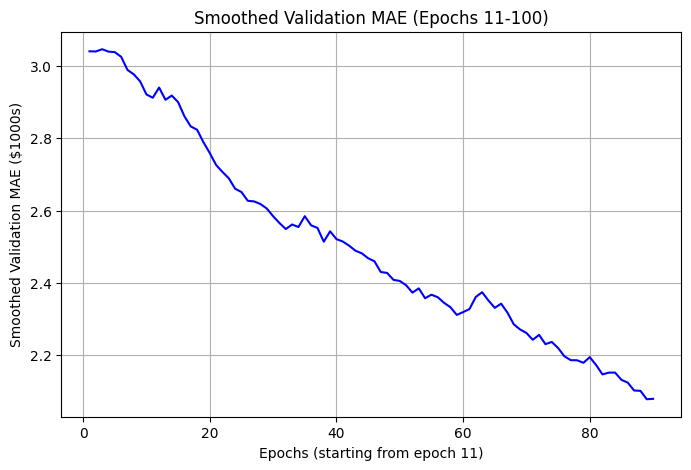


Minimum Smoothed Validation MAE: 2.0781
(Occurred around original epoch: 99)


In [10]:
import matplotlib.pyplot as plt

# 1. Define the smoothing function (exactly as provided)
def smooth_curve(points, factor=0.9):
  """Applies exponential moving average smoothing to a list of points."""
  smoothed_points = []
  for point in points:
    if smoothed_points: # Check if the list is not empty
      previous = smoothed_points[-1]
      smoothed_points.append(previous * factor + point * (1 - factor))
    else: # For the first point
      smoothed_points.append(point)
  return smoothed_points

# 2. Get the validation MAE history from the 'history' object's dictionary
#    Make sure the 'history' object from model.fit() in task 1g is available
mae_history = history.history['val_mae'] # Access the list of validation MAE values

# 3. Apply smoothing, skipping the first 10 epochs
#    mae_history[10:] creates a new list starting from the 11th element (index 10)
smooth_mae_history = smooth_curve(mae_history[10:])

# 4. Plot the smoothed curve
#    The x-axis range starts from 1 up to the number of points in the smoothed list.
#    This effectively re-indexes the epochs shown, starting from 1 on the plot,
#    but representing epochs 11 onwards from the original training.
plt.figure(figsize=(8, 5)) # Create a new figure
plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history, 'b-')
plt.title('Smoothed Validation MAE (Epochs 11-100)')
plt.xlabel('Epochs (starting from epoch 11)')
plt.ylabel('Smoothed Validation MAE ($1000s)')
plt.grid(True)
plt.show()

min_smoothed_mae = min(smooth_mae_history)
# Add 10 because we skipped the first 10, add 1 because list index starts at 0
epoch_of_min_smoothed_mae = smooth_mae_history.index(min_smoothed_mae) + 10 + 1
print(f"\nMinimum Smoothed Validation MAE: {min_smoothed_mae:.4f}")
print(f"(Occurred around original epoch: {epoch_of_min_smoothed_mae})")

Model redefined and compiled for 500-epoch training.

Starting model training for 500 epochs...
Training for 500 epochs finished.


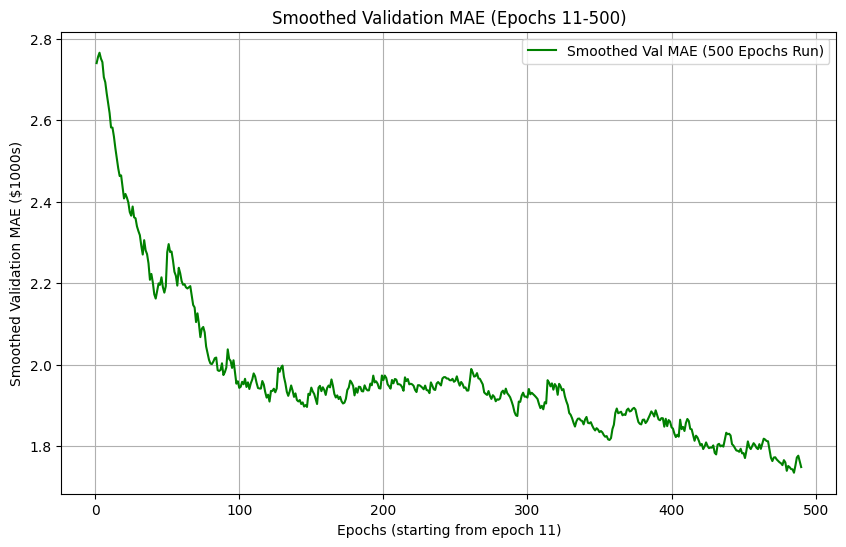

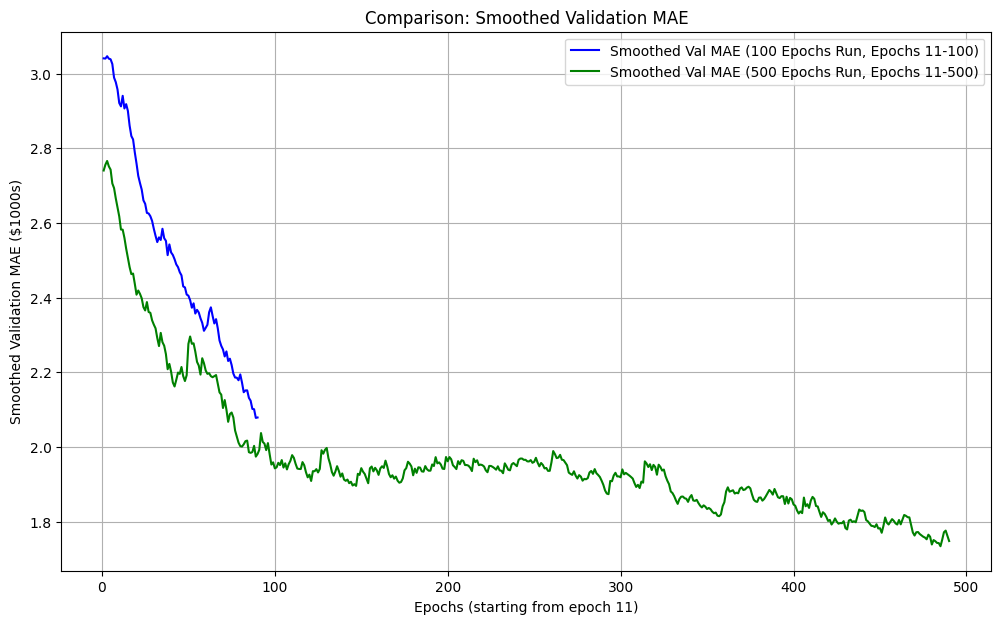


--- Comparison of Minimum Smoothed Validation MAE ---
100 Epoch Run: Min MAE = 2.0781 (around epoch 99)
500 Epoch Run: Min MAE = 1.7344 (around epoch 495)


In [11]:
# --- 1. Redefine and Recompile the Model ---
# Make sure 'build_model' function and 'scaled_train_data' are available

input_shape_for_model = (scaled_train_data.shape[1],)

# Build a fresh model instance
model_500_epochs = build_model(input_shape_for_model)

# Compile with the same settings as before
model_500_epochs.compile(optimizer='adam',
                         loss='mse',
                         metrics=['mae'])

print("Model redefined and compiled for 500-epoch training.")

# --- 2. Train for 500 Epochs ---
epochs_new = 500
batch_size = 1 # Keep the same
validation_split = 0.1 # Keep the same

print(f"\nStarting model training for {epochs_new} epochs...")

# Use verbose=0 to avoid excessive output for 500 epochs
history_500 = model_500_epochs.fit(scaled_train_data,
                                   train_targets,
                                   epochs=epochs_new,
                                   batch_size=batch_size,
                                   validation_split=validation_split,
                                   verbose=0) # Set verbose=0 for silent training

print("Training for 500 epochs finished.")

# --- 3. Plot Smoothed Validation MAE (500 Epochs) ---
# Make sure 'smooth_curve' function is available

# Get the validation MAE history from the new training run
mae_history_500 = history_500.history['val_mae']

# Apply smoothing, skipping the first 10 epochs
smooth_mae_history_500 = smooth_curve(mae_history_500[10:])

# Plot the new smoothed curve
plt.figure(figsize=(10, 6)) # Create a new figure
plt.plot(range(1, len(smooth_mae_history_500) + 1),
         smooth_mae_history_500,
         'g-', # Use green color for this plot
         label='Smoothed Val MAE (500 Epochs Run)')
plt.title('Smoothed Validation MAE (Epochs 11-500)')
plt.xlabel('Epochs (starting from epoch 11)')
plt.ylabel('Smoothed Validation MAE ($1000s)')
plt.grid(True)
plt.legend()
plt.show()

# --- 4. Plot comparison
# You can re-plot the data from the 100-epoch run on the same graph

# Get original smoothed data (ensure 'smooth_mae_history')
# smooth_mae_history_100 = smooth_mae_history

# Get epochs range for both plots
epochs_range_100 = range(1, len(smooth_mae_history) + 1)
epochs_range_500 = range(1, len(smooth_mae_history_500) + 1)

plt.figure(figsize=(12, 7))
plt.plot(epochs_range_100, smooth_mae_history, 'b-', label='Smoothed Val MAE (100 Epochs Run, Epochs 11-100)')
plt.plot(epochs_range_500, smooth_mae_history_500, 'g-', label='Smoothed Val MAE (500 Epochs Run, Epochs 11-500)')
plt.title('Comparison: Smoothed Validation MAE')
plt.xlabel('Epochs (starting from epoch 11)')
plt.ylabel('Smoothed Validation MAE ($1000s)')
plt.legend()
plt.grid(True)
plt.show()


# --- 5. Find and Print Minimums for Comparison ---
min_smoothed_mae_100 = min(smooth_mae_history) # From task 1h data
epoch_of_min_smoothed_mae_100 = smooth_mae_history.index(min_smoothed_mae_100) + 10 + 1

min_smoothed_mae_500 = min(smooth_mae_history_500)
epoch_of_min_smoothed_mae_500 = smooth_mae_history_500.index(min_smoothed_mae_500) + 10 + 1

print(f"\n--- Comparison of Minimum Smoothed Validation MAE ---")
print(f"100 Epoch Run: Min MAE = {min_smoothed_mae_100:.4f} (around epoch {epoch_of_min_smoothed_mae_100})")
print(f"500 Epoch Run: Min MAE = {min_smoothed_mae_500:.4f} (around epoch {epoch_of_min_smoothed_mae_500})")

In [12]:
# Ensure the correct model (trained for 500 epochs) and scaled test data are available
# Model: model_500_epochs
# Test Features: scaled_test_data
# Test Targets: test_targets

print("Evaluating the model trained for 500 epochs on the test set...")

# Perform evaluation
# Provide the scaled test features and the original test targets
# Keras returns a list: [loss_value, metric1_value, metric2_value, ...]
# In our case: [mse_value, mae_value]
test_results = model_500_epochs.evaluate(scaled_test_data, test_targets, verbose=1)

# Extract the results
test_loss = test_results[0] # First value is the loss (MSE)
test_mae = test_results[1]  # Second value is the metric (MAE)

print("\n--- Test Set Evaluation Results ---")
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Calculate and interpret MAE in dollars
average_dollar_error = test_mae * 1000
print(f"\nOn average, the model's predictions on the test set are off by: ${average_dollar_error:.2f}")

Evaluating the model trained for 500 epochs on the test set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9023 - mae: 2.2263 

--- Test Set Evaluation Results ---
Test Loss (MSE): 13.0414
Test MAE: 2.4255

On average, the model's predictions on the test set are off by: $2425.53
